# Chapter 4: Deep Convolutional GAN (DCGAN)

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from keras.datasets import mnist
from keras.layers import (Activation, BatchNormalization, Conv2D, Conv2DTranspose,
                          Dense, Dropout, Flatten, LeakyReLU, Reshape)
from keras.models import Sequential
from keras.optimizers import Adam

2026-03-03 13:51:29.386939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 13:51:29.420722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 13:51:30.292629: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
img_rows = 28
img_cols = 28
channels = 1

# Input image dimensions
img_shape = (img_rows, img_cols, channels)

# Size of the noise vector, used as input to the Generator
z_dim = 100

## Generator
- Generator employs Conv2DTranspose for spatial upsampling which is the inverse of what a regular convolution does.
- Final output will be 28x28x1 image 

NOTE:
An alternative is UpSampling2D (nearest-neighbour resize) followed by a regular Conv2D. Both approaches work, but
  Conv2DTranspose is preferred in DCGAN because:

  - It learns how to upsample — the upsampling kernel weights are trained, not fixed
  - It combines upsampling and feature learning in a single operation
  - The original DCGAN paper (Radford et al. 2015) specifically recommends it over pooling/upsampling layers


In [3]:
def build_generator(z_dim):

    model = Sequential()

    # Reshape input into 7x7x256 tensor via a fully connected layer
    model.add(Dense(256 * 7 * 7))    # noise z (100,) → flat (256×7×7,)
    model.add(Reshape((7, 7, 256)))  # → 7×7×256

    # Transposed convolution layer, from 7x7x256 into 14x14x128 tensor
    model.add(Conv2DTranspose(128, kernel_size=3, strides=2, padding='same'))

    # Batch normalization
    model.add(BatchNormalization())

    # Leaky ReLU activation
    model.add(LeakyReLU(negative_slope=0.01))

    # Transposed convolution layer, from 14x14x128 to 14x14x64 tensor
    model.add(Conv2DTranspose(64, kernel_size=3, strides=1, padding='same'))

    # Batch normalization
    model.add(BatchNormalization())

    # Leaky ReLU activation
    model.add(LeakyReLU(negative_slope=0.01))

    # Transposed convolution layer, from 14x14x64 to 28x28x1 tensor
    model.add(Conv2DTranspose(1, kernel_size=3, strides=2, padding='same'))

    # Output layer with tanh activation
    model.add(Activation('tanh'))

    return model

## Discriminator

In [4]:
def build_discriminator(img_shape):

    model = Sequential()

    # Convolutional layer, from 28x28x1 into 14x14x32 tensor
    model.add(Conv2D(32, kernel_size=3, strides=2, input_shape=img_shape, padding='same'))

    # Leaky ReLU activation
    model.add(LeakyReLU(negative_slope=0.01))

    # Convolutional layer, from 14x14x32 into 7x7x64 tensor
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same'))

    # Batch normalization
    model.add(BatchNormalization())

    # Leaky ReLU activation
    model.add(LeakyReLU(negative_slope=0.01))

    # Convolutional layer, from 7x7x64 tensor into 3x3x128 tensor
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same'))

    # Batch normalization
    model.add(BatchNormalization())

    # Leaky ReLU activation
    model.add(LeakyReLU(negative_slope=0.01))

    # Output layer with sigmoid activation
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

## Build the Model

In [6]:
# Build the Discriminator and Generator
discriminator = build_discriminator(img_shape)
generator = build_generator(z_dim)

# Separate optimizers — one for each model.
# In Keras 3, trainable=False is evaluated dynamically at every step, not baked
# in at compile() time. The old compile()+train_on_batch() trick is broken.
# Fix: use tf.GradientTape to explicitly control which variables get updated.
d_optimizer = Adam()
g_optimizer = Adam()

cross_entropy = tf.keras.losses.BinaryCrossentropy()

/home/changsung/ml-tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772506315.355090  708818 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1195 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## Training

In [7]:
losses = []
accuracies = []
iteration_checkpoints = []


def train_discriminator_step(real_imgs, batch_size):
    """Update only discriminator weights using GradientTape."""
    z = tf.random.normal((batch_size, z_dim))
    real_labels = tf.ones((batch_size, 1))
    fake_labels = tf.zeros((batch_size, 1))

    with tf.GradientTape() as tape:
        fake_imgs = generator(z, training=False)          # generator frozen
        real_output = discriminator(real_imgs, training=True)
        fake_output = discriminator(fake_imgs, training=True)
        d_loss = (cross_entropy(real_labels, real_output)
                  + cross_entropy(fake_labels, fake_output)) / 2

    # Apply gradients only to discriminator variables
    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))

    real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
    fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))
    accuracy = (real_acc + fake_acc) / 2

    return float(d_loss), float(accuracy)


def train_generator_step(batch_size):
    """Update only generator weights using GradientTape."""
    z = tf.random.normal((batch_size, z_dim))
    real_labels = tf.ones((batch_size, 1))

    with tf.GradientTape() as tape:
        fake_imgs = generator(z, training=True)
        fake_output = discriminator(fake_imgs, training=False)  # discriminator frozen
        g_loss = cross_entropy(real_labels, fake_output)

    # Apply gradients only to generator variables
    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    return float(g_loss)


def train(iterations, batch_size, sample_interval):

    # Load the MNIST dataset
    (X_train, _), (_, _) = mnist.load_data()

    # Rescale [0, 255] grayscale pixel values to [-1, 1]
    X_train = X_train / 127.5 - 1.0
    X_train = np.expand_dims(X_train, axis=3).astype('float32')

    for iteration in range(iterations):

        # -------------------------
        #  Train the Discriminator
        # -------------------------

        # Get a random batch of real images
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_imgs = tf.constant(X_train[idx])

        d_loss, accuracy = train_discriminator_step(real_imgs, batch_size)

        # ---------------------
        #  Train the Generator
        # ---------------------

        g_loss = train_generator_step(batch_size)

        if (iteration + 1) % sample_interval == 0:

            # Save losses and accuracies so they can be plotted after training
            losses.append((d_loss, g_loss))
            accuracies.append(100.0 * accuracy)
            iteration_checkpoints.append(iteration + 1)

            # Output training progress
            print("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" %
                  (iteration + 1, d_loss, 100.0 * accuracy, g_loss))

            # Output a sample of generated image
            sample_images(generator)

In [ ]:
losses = []
accuracies = []
iteration_checkpoints = []


def train_discriminator_step(real_imgs, batch_size):
    """Update only discriminator weights using GradientTape."""
    z = tf.random.normal((batch_size, z_dim))
    real_labels = tf.ones((batch_size, 1))
    fake_labels = tf.zeros((batch_size, 1))

    with tf.GradientTape() as tape:
        fake_imgs = generator(z, training=False)
        real_output = discriminator(real_imgs, training=True)
        fake_output = discriminator(fake_imgs, training=True)
        d_loss = (cross_entropy(real_labels, real_output)
                  + cross_entropy(fake_labels, fake_output)) / 2

    # Apply gradients only to discriminator variables
    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))

    real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
    fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))
    accuracy = (real_acc + fake_acc) / 2

    return float(d_loss), float(accuracy)


def train_generator_step(batch_size):
    """Update only generator weights using GradientTape."""
    z = tf.random.normal((batch_size, z_dim))
    real_labels = tf.ones((batch_size, 1))

    with tf.GradientTape() as tape:
        fake_imgs = generator(z, training=True)
        # Use training=True so discriminator's BatchNorm uses batch statistics,
        # matching the behaviour during discriminator training steps.
        # Discriminator weights are NOT updated: only generator.trainable_variables
        # are passed to apply_gradients below.
        fake_output = discriminator(fake_imgs, training=True)
        g_loss = cross_entropy(real_labels, fake_output)

    # Apply gradients only to generator variables
    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    return float(g_loss)


def train(iterations, batch_size, sample_interval):

    # Load the MNIST dataset
    (X_train, _), (_, _) = mnist.load_data()

    # Rescale [0, 255] grayscale pixel values to [-1, 1]
    X_train = X_train / 127.5 - 1.0
    X_train = np.expand_dims(X_train, axis=3).astype('float32')

    for iteration in range(iterations):

        # -------------------------
        #  Train the Discriminator
        # -------------------------

        # Get a random batch of real images
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_imgs = tf.constant(X_train[idx])

        d_loss, accuracy = train_discriminator_step(real_imgs, batch_size)

        # ---------------------
        #  Train the Generator
        # ---------------------

        g_loss = train_generator_step(batch_size)

        if (iteration + 1) % sample_interval == 0:

            # Save losses and accuracies so they can be plotted after training
            losses.append((d_loss, g_loss))
            accuracies.append(100.0 * accuracy)
            iteration_checkpoints.append(iteration + 1)

            # Output training progress
            print("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" %
                  (iteration + 1, d_loss, 100.0 * accuracy, g_loss))

            # Output a sample of generated image
            sample_images(generator)

## Train the Model and Inspect Output

**Keras 3 compatibility note:** The original code used `discriminator.trainable = False` + `compile()` to freeze the discriminator inside the GAN while keeping it trainable standalone. In Keras 3 this is broken — `trainable` is now dynamic (evaluated at every step, not baked in at compile time). The fix is `tf.GradientTape` with explicit variable lists per optimizer. See `KERAS3_COMPAT.md` Issue 6 for full details.

2026-03-03 13:52:10.987518: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1000 [D loss: 0.000023, acc.: 100.00%] [G loss: 0.001714]


2026-03-03 13:53:52.164905: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f6efc0030e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 13:53:52.164922: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-03 13:53:52.171384: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step


I0000 00:00:1772506432.686448  709277 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2000 [D loss: 0.000008, acc.: 100.00%] [G loss: 0.000565]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3000 [D loss: 0.000003, acc.: 100.00%] [G loss: 0.000335]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
4000 [D loss: 0.000002, acc.: 100.00%] [G loss: 0.000260]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
5000 [D loss: 0.000001, acc.: 100.00%] [G loss: 0.000278]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
6000 [D loss: 0.000002, acc.: 100.00%] [G loss: 0.001645]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7000 [D loss: 0.000000, acc.: 100.00%] [G loss: 0.019896]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
8000 [D loss: 0.000000, acc.: 100.00%] [G loss: 0.015712]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
9000 [D loss: 0.000000, acc.: 100.00%] [G loss: 0.018229]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
10000 [D loss: 0.000000, acc.: 100.00%] [G loss: 0.038405]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
11000 [D loss: 0.000000, acc.: 100.00%] [G loss: 0.025550]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
12000 [D loss: 0.000000, acc.: 100.00%

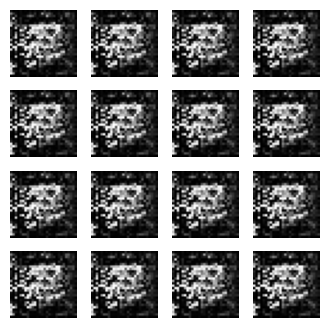

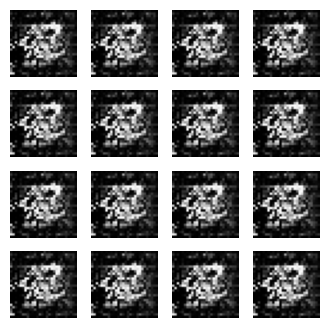

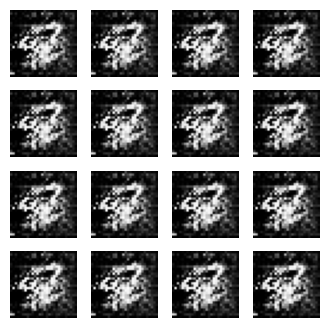

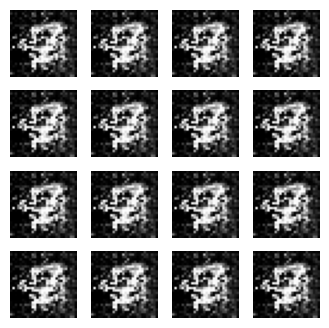

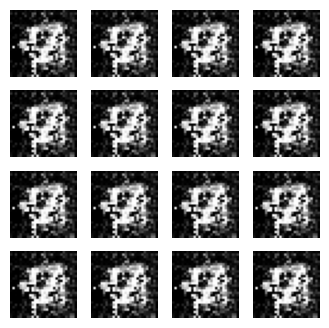

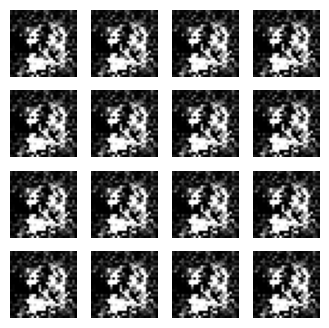

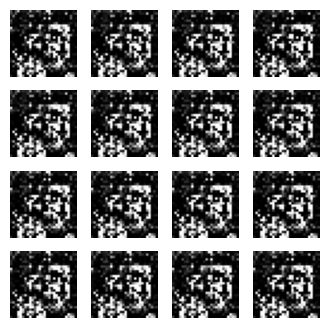

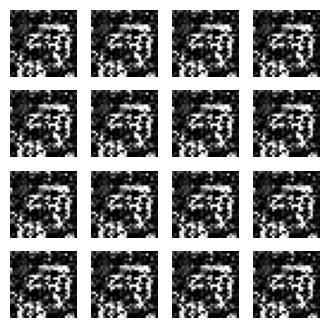

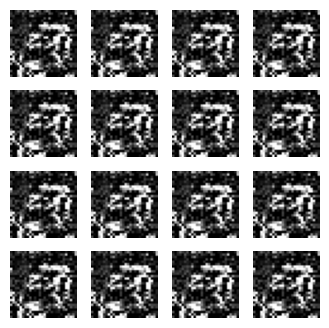

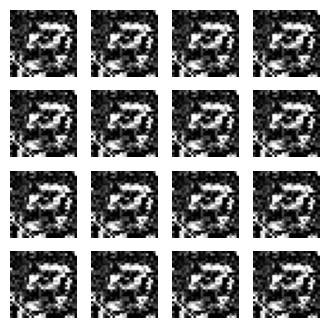

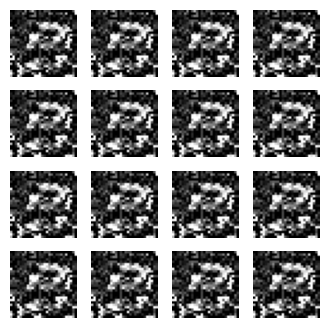

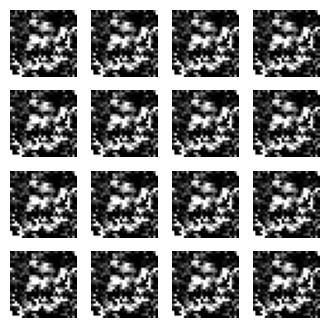

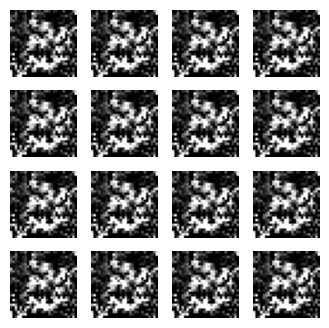

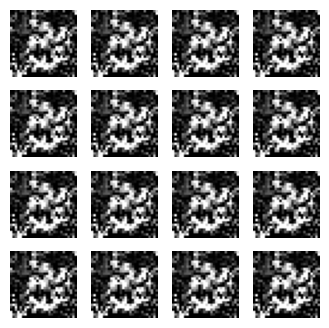

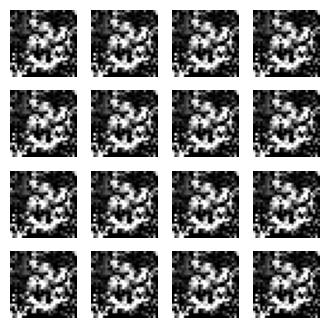

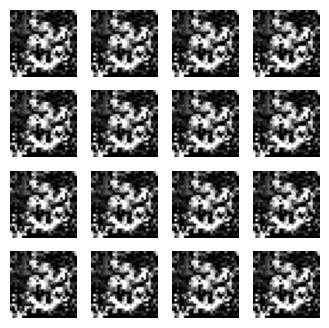

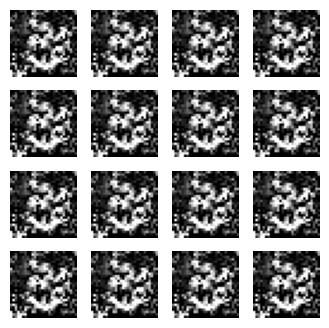

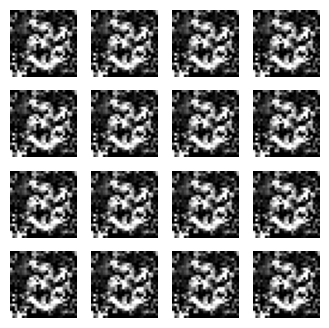

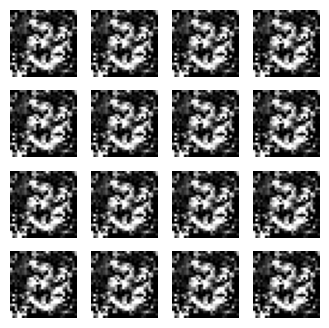

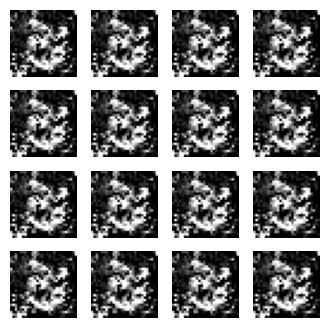

In [9]:
# Set hyperparameters
iterations = 20000
batch_size = 128
sample_interval = 1000

# Train the DCGAN for the specified number of iterations
train(iterations, batch_size, sample_interval)

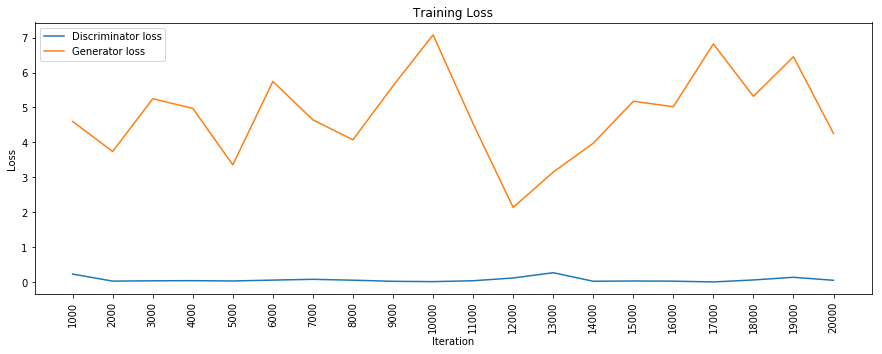

In [10]:
losses = np.array(losses)

# Plot training losses for Discriminator and Generator
plt.figure(figsize=(15, 5))
plt.plot(iteration_checkpoints, losses.T[0], label="Discriminator loss")
plt.plot(iteration_checkpoints, losses.T[1], label="Generator loss")

plt.xticks(iteration_checkpoints, rotation=90)

plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()

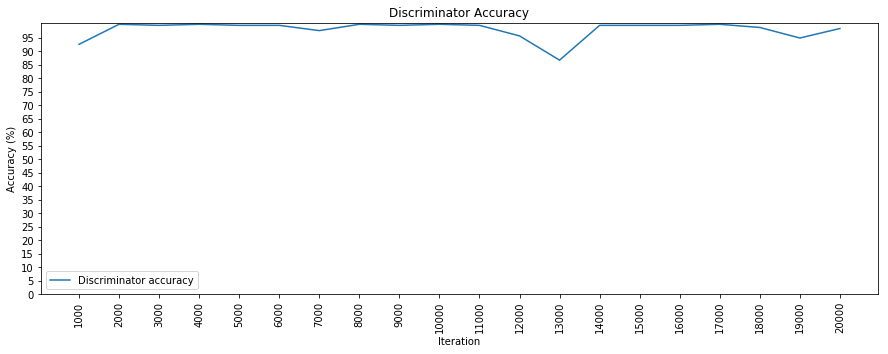

In [11]:
accuracies = np.array(accuracies)

# Plot Discriminator accuracy
plt.figure(figsize=(15, 5))
plt.plot(iteration_checkpoints, accuracies, label="Discriminator accuracy")

plt.xticks(iteration_checkpoints, rotation=90)
plt.yticks(range(0, 100, 5))

plt.title("Discriminator Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy (%)")
plt.legend()